In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("student grade.csv")
df.head()

,Name,Age,Grade,Subject,Marks,Attendance,GPA,Club,Scholarship,Remarks
0,NaN,24.0,D,History,77.0,Absent,2.09,NaN,False,NaN
1,Student_2,21.0,A,Math,49.0,Absent,NaN,Coding,True,Good
2,Student_3,22.0,NaN,Math,NaN,Present,3.25,Coding,True,Average
3,Student_4,24.0,F,Science,36.0,NaN,3.01,NaN,True,Good
4,Student_5,20.0,B,History,96.0,Absent,3.71,NaN,True,Average


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         90 non-null     object 
 1   Age          90 non-null     float64
 2   Grade        90 non-null     object 
 3   Subject      90 non-null     object 
 4   Marks        90 non-null     float64
 5   Attendance   90 non-null     object 
 6   GPA          90 non-null     float64
 7   Club         67 non-null     object 
 8   Scholarship  90 non-null     object 
 9   Remarks      90 non-null     object 
dtypes: float64(3), object(7)
memory usage: 7.9+ KB


In [5]:
df.describe()

,Age,Marks,GPA
count,90.000000,90.000000,90.000000
mean,21.155556,67.966667,3.054556
std,1.954028,19.278241,0.616965
min,18.000000,31.000000,2.040000
25%,19.000000,52.250000,2.580000
50%,21.000000,69.500000,3.160000
75%,23.000000,86.750000,3.602500
max,24.000000,99.000000,3.970000


In [6]:
df.isna().sum()

Name           10
Age            10
Grade          10
Subject        10
Marks          10
Attendance     10
GPA            10
Club           33
Scholarship    10
Remarks        10
dtype: int64

In [8]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\manan\AppData\Local\Temp\ipykernel_12352\2488166850.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)
C:\Users\manan\AppData\Local\Temp\ipykernel_12352\2488166850.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0],inplac

In [9]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\manan\AppData\Local\Temp\ipykernel_12352\1611565467.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\manan\AppData\Local\Temp\ipykernel_12352\1611565467.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [11]:
df.isna().sum()

Name           0
Age            0
Grade          0
Subject        0
Marks          0
Attendance     0
GPA            0
Club           0
Scholarship    0
Remarks        0
dtype: int64

In [12]:
df.head()

,Name,Age,Grade,Subject,Marks,Attendance,GPA,Club,Scholarship,Remarks
0,Student_10,24.0,D,History,77.0,Absent,2.09,Coding,False,Excellent
1,Student_2,21.0,A,Math,49.0,Absent,3.16,Coding,True,Good
2,Student_3,22.0,A,Math,69.5,Present,3.25,Coding,True,Average
3,Student_4,24.0,F,Science,36.0,Absent,3.01,Coding,True,Good
4,Student_5,20.0,B,History,96.0,Absent,3.71,Coding,True,Average


In [19]:
import numpy as np
def handle_outliers(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lb = Q1 - 1.5*IQR
    up = Q3 + 1.5*IQR

    outliers = df[(df[col] < lb) | (df[col] > up)]
    print(f"{col}: {len(outliers)} outliers")
    df[col] = np.where(df[col] < lb, lb, df[col])
    df[col] = np.where(df[col] > up, up, df[col])

In [20]:
for col in ['Age','GPA']:
    handle_outliers(df, col)

Age: 0 outliers
GPA: 0 outliers


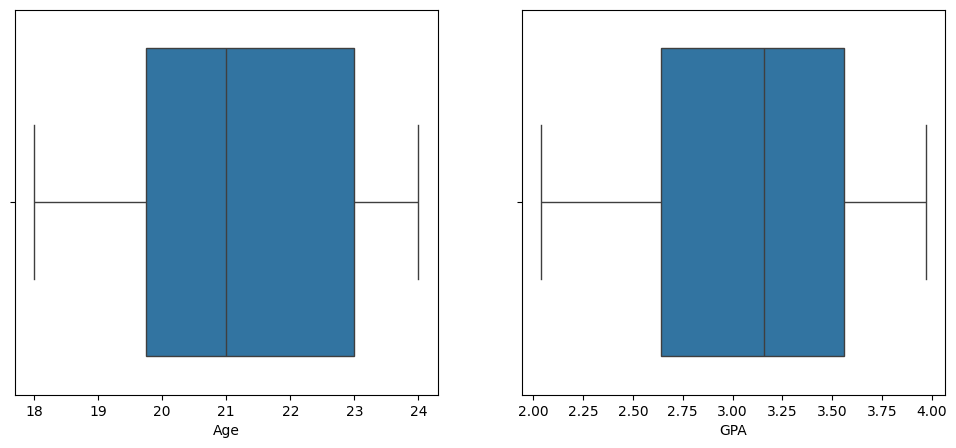

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df['Age'], ax=axes[0])
sns.boxplot(x=df['GPA'], ax=axes[1])
plt.show()
